In [ ]:
import os
import json

# Create kaggle.json directly without uploading the file
os.makedirs('/root/.kaggle', exist_ok=True)

kaggle_creds = {
    "username": "FlaSh7777",
    "key": "KGAT_2e913f60edc235e6a92c21775cfadb61"
}

with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_creds, f)

os.chmod('/root/.kaggle/kaggle.json', 0o600)
print("Done")

Done


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

os.makedirs('/content/drive/MyDrive/ham10000', exist_ok=True)
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000 -p /content/drive/MyDrive/ham10000
!unzip /content/drive/MyDrive/ham10000/skin-cancer-mnist-ham10000.zip -d /content/drive/MyDrive/ham10000

Mounted at /content/drive
Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
skin-cancer-mnist-ham10000.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  /content/drive/MyDrive/ham10000/skin-cancer-mnist-ham10000.zip
replace /content/drive/MyDrive/ham10000/HAM10000_images_part_1/ISIC_0024306.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import shutil

# IDs you want
target_ids = [
    "ISIC_0030623",
    "ISIC_0032384"
]

base_dir = "/content/drive/MyDrive/HAM10000"

# Folder where the found images will be copied
output_dir = "/content/found_images"
os.makedirs(output_dir, exist_ok=True)

for root, dirs, files in os.walk(base_dir):
    for file in files:
        for image_id in target_ids:
            if file == f"{image_id}.jpg":
                src = os.path.join(root, file)
                dst = os.path.join(output_dir, file)
                shutil.copy2(src, dst)
                print(f"Found and copied: {src}")

print("\nSaved images in:", output_dir)

Mounted at /content/drive

Saved images in: /content/found_images


In [3]:
import os

base_dir = "/content/drive/MyDrive/HAM10000"

for root, dirs, files in os.walk(base_dir):
    print(root)
    break

In [7]:
import os
import shutil

base_dir = "/content/drive/MyDrive/ham10000"
output_dir = "/content/drive/MyDrive/found_samples"

os.makedirs(output_dir, exist_ok=True)

for image_id in ["ISIC_0030623", "ISIC_0032384"]:
    for part in ["HAM10000_images_part_1", "HAM10000_images_part_2"]:
        src = os.path.join(base_dir, part, f"{image_id}.jpg")

        if os.path.exists(src):
            dst = os.path.join(output_dir, f"{image_id}.jpg")
            shutil.copy2(src, dst)
            print(f"Copied: {image_id}")
            break

print(f"\nSaved to: {output_dir}")

Copied: ISIC_0030623
Copied: ISIC_0032384

Saved to: /content/drive/MyDrive/found_samples


In [ ]:
import os

base = '/content/drive/MyDrive/ham10000'

print("Files in ham10000:")
print(os.listdir(base))

part1 = os.path.join(base, 'HAM10000_images_part_1')
part2 = os.path.join(base, 'HAM10000_images_part_2')

print(f"\nPart 1 image count: {len(os.listdir(part1))}")
print(f"Part 2 image count: {len(os.listdir(part2))}")

Files in ham10000:
['HAM10000_metadata.csv', 'hmnist_28_28_L.csv', 'hmnist_28_28_RGB.csv', 'hmnist_8_8_RGB.csv', 'hmnist_8_8_L.csv', 'skin-cancer-mnist-ham10000.zip', 'HAM10000_images_part_1', 'HAM10000_images_part_2', 'ham10000_images_part_1', 'ham10000_images_part_2', 'efficientnet_b3_skin.pth']

Part 1 image count: 5000
Part 2 image count: 5015


In [ ]:
import os

base = "/content/drive/MyDrive/ham10000"

folders = [
    "HAM10000_images_part_1",
    "ham10000_images_part_1",
    "HAM10000_images_part_2",
    "ham10000_images_part_2"
]

for f in folders:
    path = os.path.join(base, f)
    print(f, len(os.listdir(path)))

HAM10000_images_part_1 5000
ham10000_images_part_1 5000
HAM10000_images_part_2 5015
ham10000_images_part_2 5015


In [ ]:
import os

upper = set(os.listdir('/content/drive/MyDrive/ham10000/HAM10000_images_part_1'))
lower = set(os.listdir('/content/drive/MyDrive/ham10000/ham10000_images_part_1'))

print(upper == lower)

True


In [ ]:
!pip install timm -q

import os, timm, torch
import numpy as np
import pandas as pd
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

BASE       = '/content/drive/MyDrive/ham10000'
IMG_DIR_1  = os.path.join(BASE, 'HAM10000_images_part_1')
IMG_DIR_2  = os.path.join(BASE, 'HAM10000_images_part_2')
CSV_PATH   = os.path.join(BASE, 'HAM10000_metadata.csv')
SAVE_PATH  = os.path.join(BASE, 'resnet50_skin.pth')

BATCH_SIZE = 32
EPOCHS     = 15
IMG_SIZE   = 224
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {DEVICE}")

Using: cuda


In [ ]:
df = pd.read_csv(CSV_PATH)
print(df.head())
print(df.columns.tolist())
print(df['dx'].value_counts())

     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear
['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [ ]:
# Step 3a — find image path from both folders
def get_path(image_id):
    for folder in [IMG_DIR_1, IMG_DIR_2]:
        path = os.path.join(folder, image_id + '.jpg')
        if os.path.exists(path):
            return path
    return None  # safety fallback

df['path'] = df['image_id'].apply(get_path)

# Step 3b — convert text labels to numbers
# nv=0, mel=1, bkl=2 ... automatically assigned alphabetically
df['label'] = pd.Categorical(df['dx']).codes
label_names  = pd.Categorical(df['dx']).categories.tolist()
NUM_CLASSES  = len(label_names)

print(f"Number of classes: {NUM_CLASSES}")
print(f"Label mapping: {dict(enumerate(label_names))}")
print(df[['image_id', 'dx', 'label', 'path']].head(10))

Number of classes: 7
Label mapping: {0: 'akiec', 1: 'bcc', 2: 'bkl', 3: 'df', 4: 'mel', 5: 'nv', 6: 'vasc'}
       image_id   dx  label                                               path
0  ISIC_0027419  bkl      2  /content/drive/MyDrive/ham10000/HAM10000_image...
1  ISIC_0025030  bkl      2  /content/drive/MyDrive/ham10000/HAM10000_image...
2  ISIC_0026769  bkl      2  /content/drive/MyDrive/ham10000/HAM10000_image...
3  ISIC_0025661  bkl      2  /content/drive/MyDrive/ham10000/HAM10000_image...
4  ISIC_0031633  bkl      2  /content/drive/MyDrive/ham10000/HAM10000_image...
5  ISIC_0027850  bkl      2  /content/drive/MyDrive/ham10000/HAM10000_image...
6  ISIC_0029176  bkl      2  /content/drive/MyDrive/ham10000/HAM10000_image...
7  ISIC_0029068  bkl      2  /content/drive/MyDrive/ham10000/HAM10000_image...
8  ISIC_0025837  bkl      2  /content/drive/MyDrive/ham10000/HAM10000_image...
9  ISIC_0025209  bkl      2  /content/drive/MyDrive/ham10000/HAM10000_image...


In [ ]:
from sklearn.model_selection import train_test_split

# First split off test set (10%) from full data
train_val_df, test_df = train_test_split(
    df,
    test_size=0.10,
    stratify=df['label'],
    random_state=42
)

# Then split remaining into train (80%) and val (10%)
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.111,   # 0.111 of 90% ≈ 10% of total
    stratify=train_val_df['label'],
    random_state=42
)

print(f"Train: {len(train_df)}")
print(f"Val:   {len(val_df)}")
print(f"Test:  {len(test_df)}")

Train: 8012
Val:   1001
Test:  1002


In [ ]:
weights = compute_class_weight(
    'balanced',
    classes=np.arange(NUM_CLASSES),
    y=train_df['label'].values
)
weights = torch.tensor(weights, dtype=torch.float).to(DEVICE)
print(f"Class weights: {weights}")

Class weights: tensor([ 4.3853,  2.7781,  1.3021, 12.5777,  1.2846,  0.2134, 10.0401],
       device='cuda:0')


In [ ]:
train_tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),  # resize all images to 224x224
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),                    # converts PIL image to tensor [0,1]
    transforms.Normalize(                     # ImageNet mean/std — required for pretrained models
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    ),
])

val_tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    # no augmentation for val — you want to evaluate on clean images
])

class SkinDataset(Dataset):
    def __init__(self, df, transform):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = Image.open(row['path']).convert('RGB')  # open image, force RGB
        img   = self.transform(img)                      # apply transforms
        label = torch.tensor(row['label'], dtype=torch.long)
        return img, label                                # model receives (image_tensor, label_number)

In [ ]:
train_loader = DataLoader(
    SkinDataset(train_df, train_tfm),
    batch_size=BATCH_SIZE,
    shuffle=True,       # shuffle every epoch so model doesn't memorize order
    num_workers=2       # parallel workers for faster loading
)

val_loader = DataLoader(
    SkinDataset(val_df, val_tfm),
    batch_size=BATCH_SIZE,
    shuffle=False,      # no need to shuffle val
    num_workers=2
)

In [ ]:
import torchvision.models as models

# Load pretrained ResNet-50
model = models.resnet50(pretrained=True)

# Replace the final fully connected layer
# ResNet-50's default fc outputs 1000 classes (ImageNet)
# We replace it with our own layer outputting NUM_CLASSES (7)
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

# Freeze everything except the new fc layer first
for name, param in model.named_parameters():
    if 'fc' not in name:
        param.requires_grad = False

model = model.to(DEVICE)
print(model.fc)  # should show Linear(in_features=2048, out_features=7)

Linear(in_features=2048, out_features=7, bias=True)


In [ ]:
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3   # higher lr for head-only phase
)

best_val_acc = 0.0

for epoch in range(EPOCHS):

    # Unfreeze full model after epoch 3
    if epoch == 3:
        for param in model.parameters():
            param.requires_grad = True
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
        print(">> Unfroze full model, lowered LR to 1e-4")

    # ── Train ──────────────────────────────────────────────────
    model.train()
    train_loss, correct, total = 0, 0, 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()       # clear gradients from last step
        outputs = model(imgs)       # forward pass → shape: (batch, 7)
        loss    = criterion(outputs, labels)
        loss.backward()             # backprop — compute gradients
        optimizer.step()            # update weights

        train_loss += loss.item()
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += labels.size(0)

    # ── Validate ───────────────────────────────────────────────
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():           # no gradient computation during val
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs      = model(imgs)
            val_loss    += criterion(outputs, labels).item()
            val_correct += (outputs.argmax(1) == labels).sum().item()
            val_total   += labels.size(0)

    train_acc = correct / total
    val_acc   = val_correct / val_total

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {train_loss/len(train_loader):.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss/len(val_loader):.4f} | Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), SAVE_PATH)
        print(f"   ✓ Saved best model (val acc: {val_acc:.4f})")

print(f"\nDone. Best val accuracy: {best_val_acc:.4f}")

Epoch 1/15 | Train Loss: 1.5632 | Train Acc: 0.5142 | Val Loss: 1.2748 | Val Acc: 0.5904
   ✓ Saved best model (val acc: 0.5904)
Epoch 2/15 | Train Loss: 1.3168 | Train Acc: 0.5785 | Val Loss: 1.4993 | Val Acc: 0.4615
Epoch 3/15 | Train Loss: 1.2318 | Train Acc: 0.5881 | Val Loss: 1.2082 | Val Acc: 0.6214
   ✓ Saved best model (val acc: 0.6214)
>> Unfroze full model, lowered LR to 1e-4
Epoch 4/15 | Train Loss: 1.0561 | Train Acc: 0.6306 | Val Loss: 0.8137 | Val Acc: 0.6573
   ✓ Saved best model (val acc: 0.6573)
Epoch 5/15 | Train Loss: 0.8015 | Train Acc: 0.6882 | Val Loss: 0.8914 | Val Acc: 0.6593
   ✓ Saved best model (val acc: 0.6593)
Epoch 6/15 | Train Loss: 0.7213 | Train Acc: 0.7084 | Val Loss: 0.6841 | Val Acc: 0.7413
   ✓ Saved best model (val acc: 0.7413)
Epoch 7/15 | Train Loss: 0.6485 | Train Acc: 0.7292 | Val Loss: 0.7702 | Val Acc: 0.7213
Epoch 8/15 | Train Loss: 0.5627 | Train Acc: 0.7517 | Val Loss: 0.7957 | Val Acc: 0.7343
Epoch 9/15 | Train Loss: 0.5335 | Train Acc: 0

In [ ]:
# Load best saved model
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
model.eval()

test_loader = DataLoader(
    SkinDataset(test_df, val_tfm),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

test_correct, test_total = 0, 0
all_preds, all_labels    = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        outputs      = model(imgs)
        preds        = outputs.argmax(1)
        test_correct += (preds == labels).sum().item()
        test_total   += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(f"Test Accuracy: {test_correct/test_total:.4f}")

Test Accuracy: 0.8004


              precision    recall  f1-score   support

       akiec       0.42      0.85      0.57        33
         bcc       0.59      0.82      0.69        51
         bkl       0.71      0.59      0.65       110
          df       0.58      0.92      0.71        12
         mel       0.53      0.62      0.57       111
          nv       0.95      0.86      0.90       671
        vasc       0.71      0.86      0.77        14

    accuracy                           0.80      1002
   macro avg       0.64      0.79      0.69      1002
weighted avg       0.83      0.80      0.81      1002



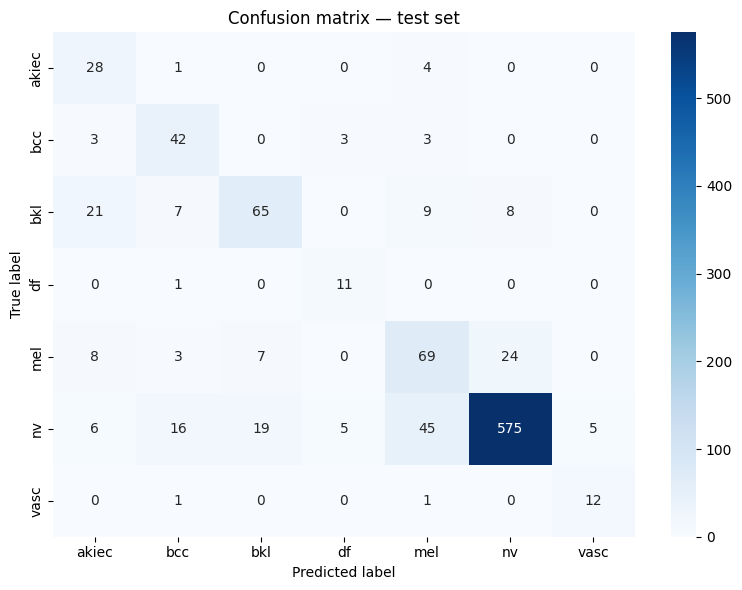

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print(classification_report(
    all_labels,
    all_preds,
    target_names=label_names
))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=label_names,
            yticklabels=label_names,
            cmap='Blues')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.title('Confusion matrix — test set')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ham10000/confusion_matrix.png')
plt.show()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 33.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


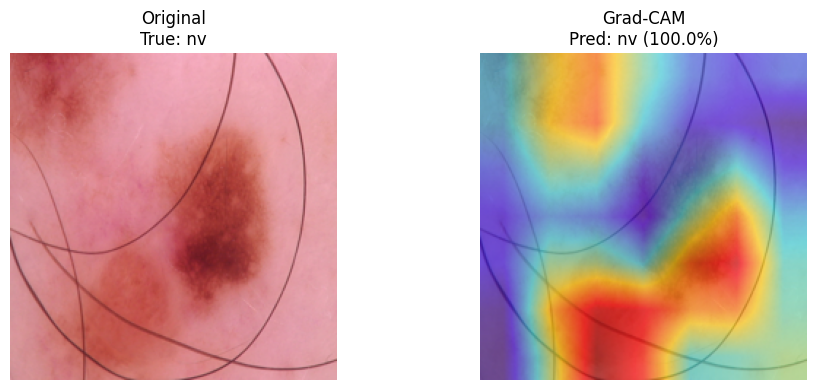

In [ ]:
!pip install grad-cam -q

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# ── Setup ─────────────────────────────────────────────────────
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
model.eval()

# Target layer — last conv layer in ResNet-50
target_layers = [model.layer4[-1]]

# ── Pick any image to visualize ───────────────────────────────
sample_row = test_df.sample(1).iloc[0]
img_path   = sample_row['path']
true_label = label_names[sample_row['label']]

# Load image twice — once for model, once for overlay
img_pil    = Image.open(img_path).convert('RGB').resize((224, 224))
img_np     = np.array(img_pil) / 255.0          # float [0,1] for overlay
img_tensor = val_tfm(img_pil).unsqueeze(0).to(DEVICE)

# ── Run GradCAM ───────────────────────────────────────────────
with GradCAM(model=model, target_layers=target_layers) as cam:
    grayscale_cam = cam(input_tensor=img_tensor, targets=None)  # None = use predicted class
    grayscale_cam = grayscale_cam[0]                             # shape: (224, 224)
    visualization = show_cam_on_image(img_np.astype(np.float32), grayscale_cam, use_rgb=True)

# ── Get prediction ────────────────────────────────────────────
with torch.no_grad():
    output    = model(img_tensor)
    pred_idx  = output.argmax(1).item()
    pred_name = label_names[pred_idx]
    confidence = torch.softmax(output, dim=1)[0][pred_idx].item()

# ── Plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(img_pil)
axes[0].set_title(f'Original\nTrue: {true_label}')
axes[0].axis('off')

axes[1].imshow(visualization)
axes[1].set_title(f'Grad-CAM\nPred: {pred_name} ({confidence*100:.1f}%)')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ham10000/gradcam_sample.png', dpi=150)
plt.show()